<a href="https://colab.research.google.com/github/jeremy280806/Game-Design-Programming/blob/main/Gauss_Seidel_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Function numpy yang akan digunakan dalam Gauss-Seidel
1. np.array() -> mengubah list menjadi array
2. np.diag() -> mencari nilai diagonal dari sebuah array
3. np.abs() -> mengabsolutkan value
4. np.fill_diagonal() -> fill value diagonal dari sebuah array
5. np.sum() -> melakukan penjumlahan
6. np.all() -> melakukan test pada semua element dalam array
7. np.zeros() -> return sebuah array yang berisi nilai 0 semua
8. np.dot() -> melakukan perkalian antar matrix
9. np.sqrt() -> melakukan pengakaran

# Function Gauss-Seidel

In [ ]:
# TODO: import numpy library
import numpy as np

# TODO: buat function untuk cek diagonally dominant
def isDiagonallyDominant(mat):
  #ambil absolute diagonal matrix
  diag = np.diag(np.abs(mat))
  #Cari penjumlahan absolute angka lain di row yg sama
  #axis = 1 -> menjumlahkan setiap baris (row)
  not_diag = np.sum(np.abs(mat), axis = 1) - diag
  #Bandingkan apakah diag >= not.diag
  if np.all(diag >= not_diag):
    return True
  else:
    return False

# TODO: buat function gauss-seidel
def gaussSeidel(X, y, epsilon = 0.01, n_iter = 10):
  #Misal: 10x1 + 4x2 + 5x3 = 8
  #Inisialisasi araay awal
  array_old = np.zeros(X.shape[0])
  #Ambil diagonal dari array
  X = X.copy()  # Copy X agar tidak mengubah array asli
  diag = np.diag(X)
  #Pindah ruas
  X = -X #X = -10x1 - 4x2 - 5x3
  np.fill_diagonal(X, 0) #X = 0x1 - 4x2 -5x3

  # Hitung gauss-seidel sebanyak n kali
  for i in range(n_iter):
    array_new = np.array(array_old) #Mengcopy hasil x1, x2, x3 dari iterasi

    for j, row in enumerate(X): # Cek untuk setiap baris yang ada di matrix X
      array_new[j] = (y[j] + np.dot(row, array_new)) / diag[j]

    print(f"Iterasi ke-{i+1}: {array_new}")

    # Hitung "jarak" (euclidean distance) antara iterasi sekarang dengan sebelummnya
    distance = np.sqrt(np.dot((array_new - array_old), (array_new - array_old)))
    if(distance <= epsilon):
      print("Hasil ditemukan");
      return array_new

    # Karena kita mau iterasi berikutnya maka array yang sekarang
    # jadi array yang lama
    array_old = array_new

  print("Hasil belum ditemukan, silahkan tambah iterasi!")
  return array_new


# Case saat hanya ada 1 persamaan
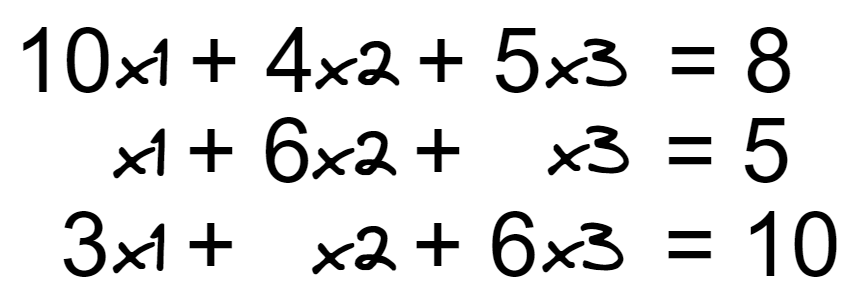

In [ ]:
# Snippet persamaan
Xs = np.array([
    [10, 4, 5],
    [1, 6, 1],
    [3, 1, 6]
])

Ys = np.array([8, 5, 10])

# TODO: implement function gauss-seidel untuk 1 persamaan
hasil = None  # Inisialisasi variabel hasil agar tidak error saat print

if isDiagonallyDominant(Xs):
  hasil = gaussSeidel(Xs, Ys)



Iterasi ke-1: [0.8  0.7  1.15]
Iterasi ke-2: [-0.055       0.65083333  1.58569444]
Iterasi ke-3: [-0.25318056  0.61124769  1.69138233]
Iterasi ke-4: [-0.29019024  0.59980132  1.7117949 ]
Iterasi ke-5: [-0.29581798  0.59733718  1.71501946]
Hasil ditemukan


# Case saat lebih dari 1 persamaan

##Persamaan 1
>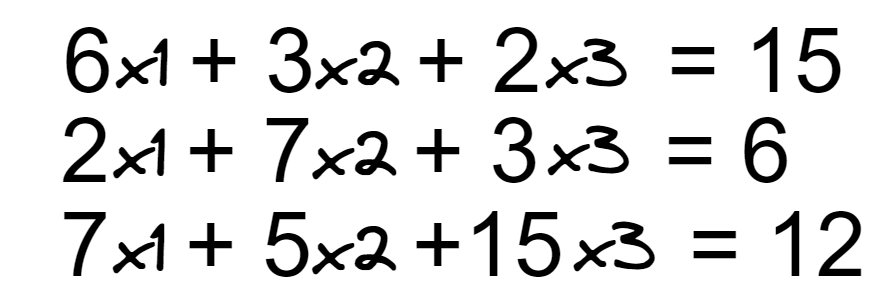

##Persamaan 2
> 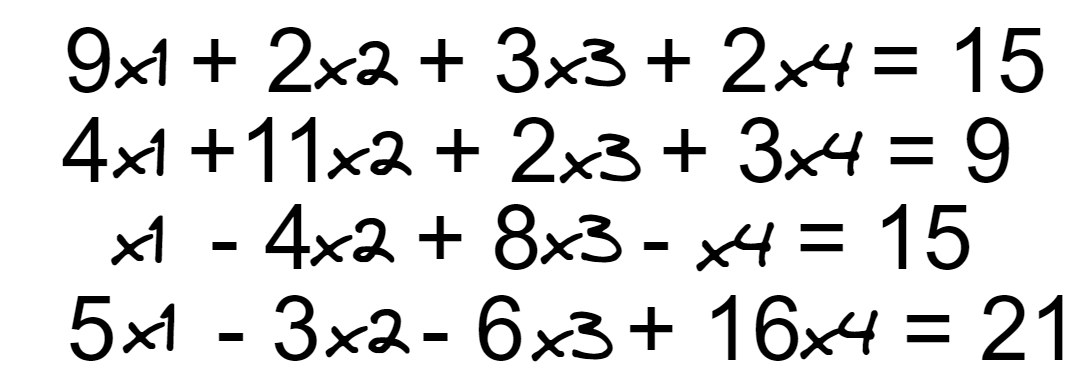

In [ ]:
# Snippet persamaan
Xm = [
    # Persamaan 1
    [
      [6, 3, 2],
      [2, 7, 3],
      [7, 5, 15]
    ],
    # Persamaan 2
    [
      [9, 2, 3, 2],
      [4, 11, 2, 3],
      [1, -4, 8, -1],
      [5, -3, -6, 16],
    ]
]

Ym = [
    # Hasil dari persamaan 1
    [8, 5, 10],
    # Hasil dari persamaan 2
    [15, 9, 15, 21]
]
# TODO: implement function gauss-seidel untuk persamaan yang lebih dari 1
hasil = []

for i, (x, y) in enumerate(zip(Xm, Ym), start=1):
  x, y = np.array(x), np.array(y)

  if isDiagonallyDominant(x):
    solusi = gaussSeidel(x, y)
    hasil.append(solusi)








Iterasi ke-1: [ 1.33333333  0.33333333 -0.06666667]
Iterasi ke-2: [ 1.18888889  0.4031746  -0.02253968]
Iterasi ke-3: [1.13925926 0.39844293 0.00219803]
Iterasi ke-4: [1.13337919 0.38952107 0.00791602]
Iterasi ke-5: [1.13593412 0.38634053 0.0077839 ]
Hasil ditemukan
Iterasi ke-1: [1.66666667 0.21212121 1.77272727 1.49621212]
Iterasi ke-2: [ 0.69612795 -0.16532752  1.89234676  1.77359114]
Iterasi ke-3: [ 0.6784925  -0.25631245  1.88373111  1.75881168]
Iterasi ke-4: [ 0.70486758 -0.26030614  1.87658994  1.74714271]
Iterasi ke-5: [ 0.71072856 -0.25795657  1.87557348  1.74537052]
Hasil ditemukan
